<a href="https://colab.research.google.com/github/Afila1996/U-Net/blob/main/Data_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
from pathlib import Path
import os
import matplotlib.pyplot as plt


##Loading dataset

In [ ]:
data_dir = Path("/content/drive/MyDrive/RAE2822_data")

db_random = np.load(os.path.join(data_dir, "db_random.npy"), allow_pickle=True).item()
airfoil = np.load(os.path.join(data_dir, "airfoil.npy"))

## db_random

In [ ]:
print("Keys in db_random:")
for k in db_random.keys():
    print(f"{k}: {np.shape(db_random[k])}")

Keys in db_random:
idx: (1007,)
Alpha: (1007,)
Vinf: (1007,)
Cl: (1007,)
Cd: (1007,)
Cm: (1007,)
Cp: (1007, 691)
Cf: (1007, 691)
Xcoordinate: (1007, 27499)
Ycoordinate: (1007, 27499)
Pressure: (1007, 27499)
Mach: (1007, 27499)
Vmag: (1007, 27499)
Temperature: (1007, 27499)
Vx: (1007, 27499)
Vy: (1007, 27499)
Airfoil: (691, 2)


##Airfoil

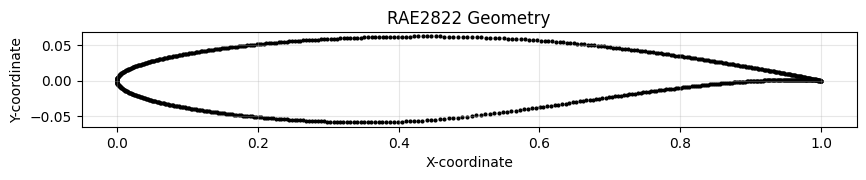

In [ ]:
plt.figure(figsize=(10, 4))
plt.scatter(airfoil[:, 0], airfoil[:, 1], s=4, c='black', label='Points')

plt.gca().set_aspect('equal', adjustable='box')
plt.title(f"RAE2822 Geometry")
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.grid(True, alpha=0.3)
plt.show()

## Finding mach_inf

In [ ]:
def freestream_temperature(x, y, temperature, far_percentile=99):

    xc = np.median(x)
    yc = np.median(y)

    r = np.sqrt((x - xc)**2 + (y - yc)**2)

    r_threshold = np.percentile(r, far_percentile)
    far = r >= r_threshold

    T_inf = np.median(temperature[far])

    return T_inf


In [ ]:
gamma = 1.4
R = 287.0

N = len(db_random["idx"])

machinf = np.zeros(N)

i=0

for i in range(N):

    x = db_random["Xcoordinate"][i]
    y = db_random["Ycoordinate"][i]
    T = db_random["Temperature"][i]
    Vinf = db_random["Vinf"][i]


    T_inf = freestream_temperature(x, y, T)

    a_inf = np.sqrt(gamma * R * T_inf)

    machinf[i] = Vinf / a_inf


##Normalising geometry

In [ ]:
def normalize_geometry(x, y, machinf, M_ref):


    s = machinf/ M_ref


    x_lo = np.quantile(x, 0.01)


    y0 = np.median(y)

    # shift + Mach scaling
    x_scaled = (x - x_lo) * s
    y_scaled = (y - y0) * s

    x_le = np.quantile(x_scaled, 0.01)
    x_tr = np.quantile(x_scaled, 0.99)

    chord = x_tr - x_le


    xN = x_scaled / chord
    yN = y_scaled / chord

    return xN, yN


In [ ]:
# reference Mach
M_ref = np.mean(machinf)

xN_all = []
yN_all = []

i=0

for i in range(N):

    x = db_random["Xcoordinate"][i]
    y = db_random["Ycoordinate"][i]
    xN, yN = normalize_geometry(x, y, machinf[i], M_ref)

    xN_all.append(xN)
    yN_all.append(yN)


##Grid

In [ ]:
xmin, xmax = -0.3, 1.3
ymin, ymax = -0.6, 0.6


Nx, Ny = 128, 128


x_lin = np.linspace(xmin, xmax, Nx)
y_lin = np.linspace(ymin, ymax, Ny)

Xg, Yg = np.meshgrid(x_lin, y_lin)


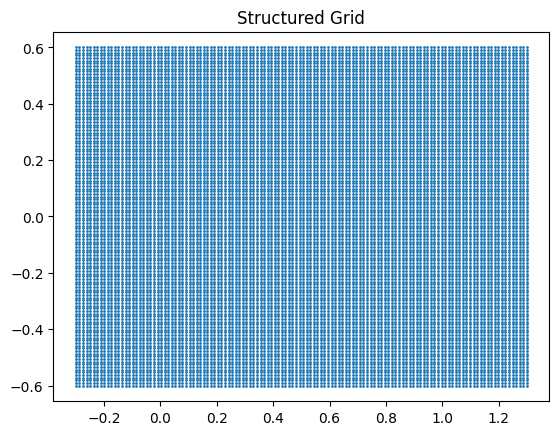

In [ ]:
plt.scatter(Xg, Yg, s=1)
plt.axis('equal')
plt.title("Structured Grid")
plt.show()


##Interpolation

In [ ]:
from scipy.interpolate import griddata


def interpolate_to_grid(x, y, values, Xg, Yg, method='cubic'):

    pts = np.column_stack([x, y])

    Z = griddata(pts, values, (Xg, Yg), method=method)

    # fill holes
    if np.isnan(Z).any():
        Z_nn = griddata(pts, values, (Xg, Yg), method='nearest')
        Z = np.where(np.isnan(Z), Z_nn, Z)

    return Z.astype(np.float32)


In [ ]:
from matplotlib.path import Path
def airfoil_mask(Airfoil, Xg, Yg):


    airfoil_path = Path(airfoil)


    grid_points = np.column_stack((Xg.ravel(), Yg.ravel()))


    inside = airfoil_path.contains_points(grid_points)

    mask = inside.reshape(Xg.shape)

    return mask.astype(np.float32)


airfoil_mask = airfoil_mask(airfoil, Xg, Yg)

In [ ]:
def interpolation(xN, yN, u, v, p, mach_inf, aoa, airfoil_mask, Xg, Yg):

    # interpolate outputs
    u_g = interpolate_to_grid(xN, yN, u, Xg, Yg)
    v_g = interpolate_to_grid(xN, yN, v, Xg, Yg)
    p_g = interpolate_to_grid(xN, yN, p, Xg, Yg)


    #coordinate channels
    xmin, xmax = Xg.min(), Xg.max()
    ymin, ymax = Yg.min(), Yg.max()

    xchan = 2*(Xg-xmin)/(xmax-xmin)-1
    ychan = 2*(Yg-ymin)/(ymax-ymin)-1


    mach_chan = np.full_like(xchan, mach_inf)
    aoa_chan = np.full_like(xchan, aoa)

    #build input tensor
    X_in = np.stack([xchan, ychan, airfoil_mask, mach_chan, aoa_chan], axis=0)

    # build output tensor
    Y_out = np.stack([p_g, u_g, v_g], axis=0)

    return X_in.astype(np.float32), Y_out.astype(np.float32)


In [ ]:
dataset_inputs = []
dataset_outputs = []

for i in range(N):

    xN = xN_all[i]
    yN = yN_all[i]

    u = db_random["Vx"][i]
    v = db_random["Vy"][i]
    p = db_random["Pressure"][i]


    mach_inf = machinf[i]
    aoa = db_random["Alpha"][i]

    X_in, Y_out = interpolation(xN, yN, u, v, p, mach_inf, aoa, airfoil_mask, Xg, Yg)

    dataset_inputs.append(X_in)
    dataset_outputs.append(Y_out)


In [ ]:
dataset_inputs = np.stack(dataset_inputs)
dataset_outputs = np.stack(dataset_outputs)

print("Input tensor:",dataset_inputs.shape)
print("Output tensor:",dataset_outputs.shape)


Input tensor: (1007, 5, 128, 128)
Output tensor: (1007, 3, 128, 128)


## Data Loader

In [ ]:
import os
import pandas as pd
from torchvision.io import decode_image